In [1]:
!nvidia-smi

Wed Sep 30 06:51:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Self-Supervised and Contrastive Representation Learning on STL-10

**Course:** DATA 266 — Generative AI and Large Language Models  
**Assignment:** Self-Supervised and Contrastive Representation Learning  
**Dataset:** STL-10  
**Backbone:** ResNet-18 without pretrained weights  
**Student:** Naga Sai Haritha Gottumukkala  

## Standing Personal Parameters

The following values were calculated using the last four digits of my student ID.

- `SID4 = 1598`
- `SEED = 1598`
- `SLICE = 1598 mod 1000 = 598`
- `HP_ID = 1598 mod 6 = 2`
- `CLS_A = 1598 mod 10 = 8`
- `CLS_B = (8 + 1 + ((1598 // 10) mod 9)) mod 10 = 5`

For STL-10, class 8 is **ship** and class 5 is **dog**. These focus classes are reported here because they are part of the standing requirements. This assignment does not explicitly require them for model training.

`HP_ID = 2` corresponds to the learning-rate-high arm. However, the standing instructions state that HP_ID should only be applied when a homework provides a specific HP_ID mapping. Since this assignment does not provide such a mapping, I do not use HP_ID to change the learning rate.

## Assignment Goal

The goal of this experiment is to compare three ways of learning image representations:

1. Supervised learning using only 10% of the labeled STL-10 training set.
2. Self-supervised learning by predicting image rotations.
3. SimCLR-style contrastive learning using two augmented views of each image.

All three experiments use the same ResNet-18 backbone with randomly initialized weights. The models are compared using test accuracy and cosine-similarity nearest-neighbor retrieval.

In [2]:
# Standard Python libraries
import os
import sys
import time
import random
import platform
from datetime import datetime
from pathlib import Path

# Numerical and data-handling libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.transforms import functional as TF

# Evaluation tools
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Progress bar
from tqdm.auto import tqdm


# ---------------------------------------------------------
# Personal and reproducibility settings
# ---------------------------------------------------------

SID4 = 1598
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10


def set_seed(seed):
    """Set the main random seeds used in this notebook."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # These settings improve reproducibility.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Warn instead of stopping if an operation has no deterministic version.
    torch.use_deterministic_algorithms(True, warn_only=True)


def seed_worker(worker_id):
    """Give every DataLoader worker a reproducible random seed."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(SEED)

# This generator will be passed to DataLoaders that shuffle data.
data_generator = torch.Generator()
data_generator.manual_seed(SEED)


# ---------------------------------------------------------
# Device selection
# ---------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Notebook started at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python version:", platform.python_version())
print("PyTorch version:", torch.__version__)
print("Torchvision version:", __import__("torchvision").__version__)
print("CUDA available:", torch.cuda.is_available())
print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

print("\nPersonal parameters")
print("-------------------")
print("SID4 :", SID4)
print("SEED :", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

Notebook started at: 2026-09-30 06:52:29
Python version: 3.13.15
PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available: True
Selected device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

Personal parameters
-------------------
SID4 : 1598
SEED : 1598
SLICE: 598
HP_ID: 2
CLS_A: 8
CLS_B: 5


## Load the STL-10 Dataset

STL-10 contains 5,000 labeled training images, 100,000 unlabeled images and 8,000 test images. The unlabeled images will be used for rotation and SimCLR training.

In [3]:
data_dir = "./data"

train_raw = datasets.STL10(
    root=data_dir,
    split="train",
    download=True,
    transform=None
)

unlabeled_raw = datasets.STL10(
    root=data_dir,
    split="unlabeled",
    download=True,
    transform=None
)

test_raw = datasets.STL10(
    root=data_dir,
    split="test",
    download=True,
    transform=None
)

class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

print("Labeled training images:", len(train_raw))
print("Unlabeled images:", len(unlabeled_raw))
print("Test images:", len(test_raw))
print("Classes:", class_names)

100%|██████████| 2.64G/2.64G [09:47<00:00, 4.50MB/s]


Labeled training images: 5000
Unlabeled images: 100000
Test images: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## Check the Labeled Images

I display one training image from each class to check the dataset and labels.

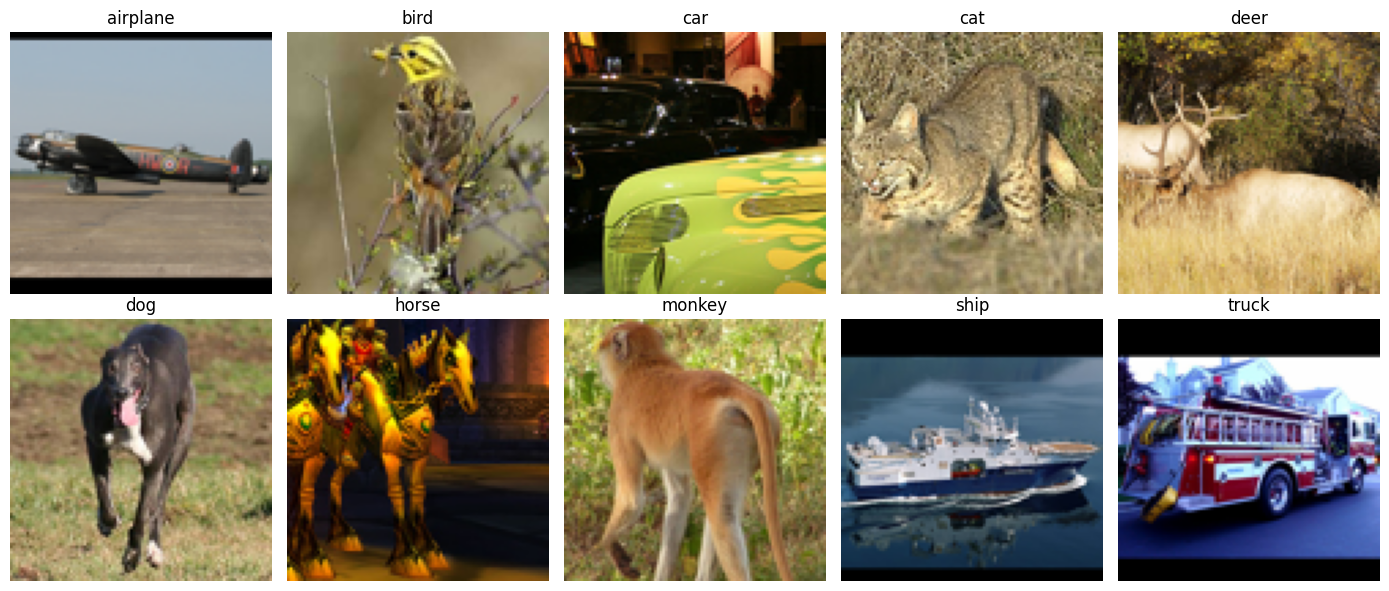

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

train_labels = np.array(train_raw.labels)

for class_id, ax in enumerate(axes.flat):
    image_index = np.where(train_labels == class_id)[0][0]
    image, label = train_raw[image_index]

    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Select 10% of the Labeled Training Set

I use 500 labeled images, with 50 images from each class. The same subset will be used for all three models.

In [5]:
rng = np.random.default_rng(SEED)
selected_indices = []

for class_id in range(10):
    class_indices = np.where(train_labels == class_id)[0]
    chosen = rng.choice(class_indices, size=50, replace=False)
    selected_indices.extend(chosen)

selected_indices = np.array(selected_indices)
rng.shuffle(selected_indices)

selected_labels = train_labels[selected_indices]

print("Selected images:", len(selected_indices))

for class_id, class_name in enumerate(class_names):
    count = np.sum(selected_labels == class_id)
    print(f"{class_name}: {count}")

Selected images: 500
airplane: 50
bird: 50
car: 50
cat: 50
deer: 50
dog: 50
horse: 50
monkey: 50
ship: 50
truck: 50


# Part A — Supervised Learning with Limited Labels

**Question:** Use 10% of the labeled training set, train ResNet-18 end-to-end for about 10–15 epochs and report test accuracy.

I use the same 500 selected images and train ResNet-18 for 15 epochs.

In [6]:
stl_mean = (0.4467, 0.4398, 0.4066)
stl_std = (0.2603, 0.2566, 0.2713)

train_transform = transforms.Compose([
    transforms.RandomCrop(96, padding=12),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std)
])

train_dataset = datasets.STL10(
    root=data_dir,
    split="train",
    download=False,
    transform=train_transform
)

test_dataset = datasets.STL10(
    root=data_dir,
    split="test",
    download=False,
    transform=test_transform
)

supervised_subset = Subset(train_dataset, selected_indices)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

supervised_loader = DataLoader(
    supervised_subset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=loader_generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(supervised_loader))

print("Training batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Training images:", len(supervised_subset))
print("Test images:", len(test_dataset))

Training batch shape: torch.Size([64, 3, 96, 96])
Label batch shape: torch.Size([64])
Training images: 500
Test images: 8000


## Supervised ResNet-18

The model starts with random weights. Both the encoder and classification layer will be updated during training.

In [7]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)


torch.manual_seed(SEED)

supervised_encoder = ResNet18Encoder().to(device)
supervised_classifier = nn.Linear(512, 10).to(device)

supervised_model = nn.Sequential(
    supervised_encoder,
    supervised_classifier
).to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in supervised_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in supervised_model.parameters()
    if parameter.requires_grad
)

print("Model: ResNet-18")
print("Pretrained weights: No")
print("Output classes: 10")
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")

Model: ResNet-18
Pretrained weights: No
Output classes: 10
Total parameters: 11,181,642
Trainable parameters: 11,181,642


## Train the Supervised Model

I train the complete ResNet-18 using cross-entropy loss. Since only 500 labeled images are available, data augmentation is used to reduce overfitting.

In [8]:
supervised_epochs = 15

supervised_loss_function = nn.CrossEntropyLoss()

supervised_optimizer = torch.optim.AdamW(
    supervised_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

supervised_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    supervised_optimizer,
    T_max=supervised_epochs
)

supervised_history = {
    "loss": [],
    "accuracy": []
}

for epoch in range(1, supervised_epochs + 1):
    supervised_model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    progress_bar = tqdm(
        supervised_loader,
        desc=f"Epoch {epoch}/{supervised_epochs}"
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        supervised_optimizer.zero_grad(set_to_none=True)

        predictions = supervised_model(images)
        loss = supervised_loss_function(predictions, labels)

        loss.backward()
        supervised_optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct_predictions += (
            predictions.argmax(dim=1) == labels
        ).sum().item()
        total_images += batch_size

    epoch_loss = running_loss / total_images
    epoch_accuracy = 100 * correct_predictions / total_images

    supervised_history["loss"].append(epoch_loss)
    supervised_history["accuracy"].append(epoch_accuracy)

    supervised_scheduler.step()

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch 1/15:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 01 | Loss: 2.2059 | Training Accuracy: 19.80%


Epoch 2/15:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 02 | Loss: 1.9465 | Training Accuracy: 30.80%


Epoch 3/15:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 14/15:   0%|          | 0/8 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cb665f58040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7cb665f58040>
assert self._parent_pid == os.getpid(), 'can only test a child process'Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
AssertionError    : if w.is_alive():
can only test a child process  File "/usr/lib/p

Epoch 14 | Loss: 0.7357 | Training Accuracy: 75.20%


Epoch 15/15:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 15 | Loss: 0.7205 | Training Accuracy: 75.40%


## Supervised Test Accuracy

I now evaluate the supervised model on the 8,000 test images.

In [9]:
supervised_model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        predictions = supervised_model(images)
        loss = supervised_loss_function(predictions, labels)

        test_loss_sum += loss.item() * labels.size(0)
        test_correct += (
            predictions.argmax(dim=1) == labels
        ).sum().item()
        test_total += labels.size(0)

supervised_test_loss = test_loss_sum / test_total
supervised_test_accuracy = 100 * test_correct / test_total

print(f"Test Loss: {supervised_test_loss:.4f}")
print(f"Test Accuracy: {supervised_test_accuracy:.2f}%")

Testing:   0%|          | 0/32 [00:00<?, ?it/s]

Test Loss: 1.6781
Test Accuracy: 44.15%


### Part A Result

The supervised model reached **44.15% test accuracy**. Its final training accuracy was 75.40%, so the difference shows that the model overfitted the small labeled dataset.

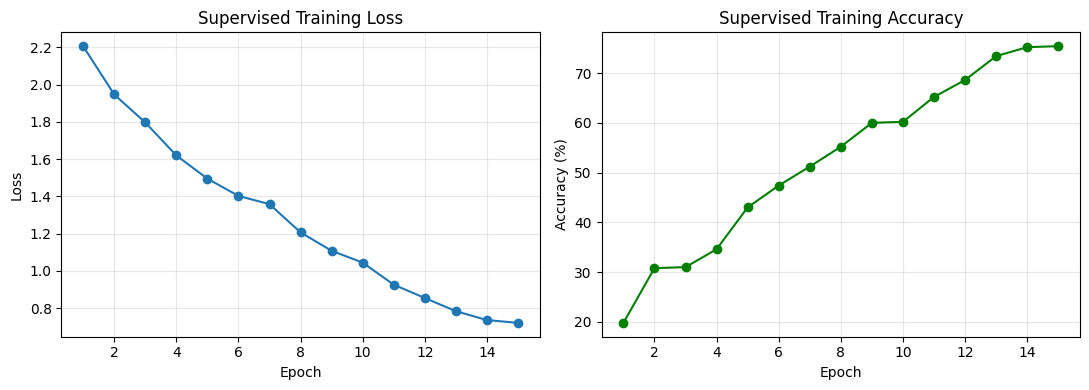

In [10]:
epochs = range(1, supervised_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, supervised_history["loss"], marker="o")
axes[0].set_title("Supervised Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    supervised_history["accuracy"],
    marker="o",
    color="green"
)
axes[1].set_title("Supervised Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
import os

os.makedirs("/content/checkpoints", exist_ok=True)

np.save(
    "/content/checkpoints/labeled_500_indices.npy",
    selected_indices
)

torch.save(
    {
        "seed": SEED,
        "epochs": supervised_epochs,
        "encoder_state_dict": supervised_encoder.state_dict(),
        "classifier_state_dict": supervised_classifier.state_dict(),
        "test_loss": supervised_test_loss,
        "test_accuracy": supervised_test_accuracy
    },
    "/content/checkpoints/supervised_resnet18.pt"
)

print("Supervised checkpoint saved.")
print("Selected indices saved.")

Supervised checkpoint saved.
Selected indices saved.


# Part B — Rotation Self-Supervised Learning

**Question:** Use all unlabeled images and train an encoder to predict rotations of 0°, 90°, 180° and 270° for about 15 epochs.

The rotation label is created automatically, so the original class label is not used.

In [12]:
rotation_transform = transforms.Compose([
    transforms.RandomCrop(96, padding=12),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std)
])


class RotationDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        image, _ = self.base_dataset[index]

        rotation_label = random.randint(0, 3)
        angle = rotation_label * 90

        rotated_image = transforms.functional.rotate(image, angle)
        rotated_image = self.transform(rotated_image)

        return rotated_image, rotation_label


rotation_dataset = RotationDataset(
    unlabeled_raw,
    rotation_transform
)

rotation_generator = torch.Generator()
rotation_generator.manual_seed(SEED)

rotation_loader = DataLoader(
    rotation_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=rotation_generator
)

rotation_images, rotation_labels = next(iter(rotation_loader))

print("Unlabeled images:", len(rotation_dataset))
print("Batch shape:", rotation_images.shape)
print("Rotation labels:", torch.unique(rotation_labels).tolist())

Unlabeled images: 100000
Batch shape: torch.Size([256, 3, 96, 96])
Rotation labels: [0, 1, 2, 3]


## Check the Four Rotations

I display one unlabeled image in all four rotations to confirm that the rotation labels are correct.

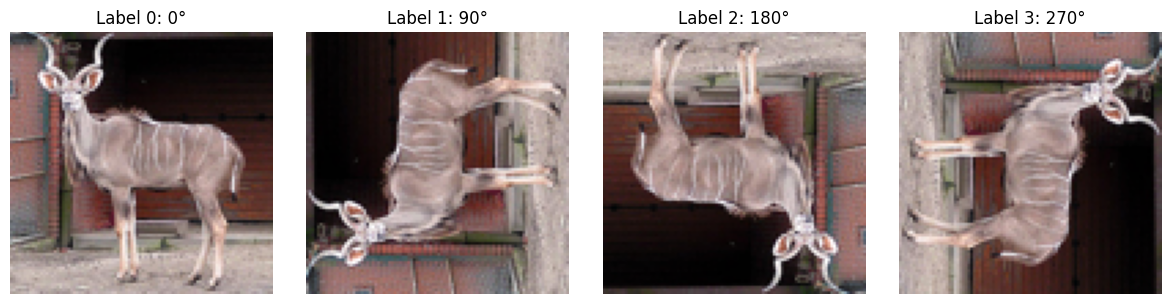

In [13]:
sample_image, _ = unlabeled_raw[0]

rotation_angles = [0, 90, 180, 270]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for ax, angle in zip(axes, rotation_angles):
    rotated_image = transforms.functional.rotate(
        sample_image,
        angle
    )

    ax.imshow(rotated_image)
    ax.set_title(f"Label {angle // 90}: {angle}°")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Rotation Prediction Model

I attach a four-class rotation head to a new ResNet-18 encoder. Both parts will be trained using the unlabeled images.

In [14]:
torch.manual_seed(SEED)

rotation_encoder = ResNet18Encoder().to(device)
rotation_head = nn.Linear(512, 4).to(device)

rotation_model = nn.Sequential(
    rotation_encoder,
    rotation_head
).to(device)

rotation_parameters = sum(
    parameter.numel()
    for parameter in rotation_model.parameters()
)

print("Encoder: ResNet-18")
print("Pretrained weights: No")
print("Rotation classes: 4")
print("Total parameters:", f"{rotation_parameters:,}")

Encoder: ResNet-18
Pretrained weights: No
Rotation classes: 4
Total parameters: 11,178,564


## Train the Rotation Model

The model learns to predict the rotation of each unlabeled image. Mixed precision is used to make training faster on the T4 GPU.

In [15]:
import time

rotation_epochs = 15
rotation_loss_function = nn.CrossEntropyLoss()

rotation_optimizer = torch.optim.AdamW(
    rotation_model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

rotation_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    rotation_optimizer,
    T_max=rotation_epochs
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

rotation_history = {
    "loss": [],
    "accuracy": [],
    "time": []
}

for epoch in range(1, rotation_epochs + 1):
    rotation_model.train()

    start_time = time.time()
    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    progress_bar = tqdm(
        rotation_loader,
        desc=f"Rotation Epoch {epoch}/{rotation_epochs}"
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        rotation_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):
            predictions = rotation_model(images)
            loss = rotation_loss_function(predictions, labels)

        scaler.scale(loss).backward()
        scaler.step(rotation_optimizer)
        scaler.update()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct_predictions += (
            predictions.argmax(dim=1) == labels
        ).sum().item()
        total_images += batch_size

    epoch_loss = running_loss / total_images
    epoch_accuracy = 100 * correct_predictions / total_images
    epoch_time = time.time() - start_time

    rotation_history["loss"].append(epoch_loss)
    rotation_history["accuracy"].append(epoch_accuracy)
    rotation_history["time"].append(epoch_time)

    rotation_scheduler.step()

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Rotation Accuracy: {epoch_accuracy:.2f}% | "
        f"Time: {epoch_time / 60:.2f} min"
    )

    torch.save(
        {
            "epoch": epoch,
            "encoder_state_dict": rotation_encoder.state_dict(),
            "rotation_head_state_dict": rotation_head.state_dict(),
            "optimizer_state_dict": rotation_optimizer.state_dict(),
            "history": rotation_history
        },
        "/content/checkpoints/rotation_latest.pt"
    )

Rotation Epoch 1/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 01 | Loss: 1.1378 | Rotation Accuracy: 45.48% | Time: 2.09 min


Rotation Epoch 2/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 02 | Loss: 0.9839 | Rotation Accuracy: 52.89% | Time: 2.26 min


Rotation Epoch 3/15:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 13 | Loss: 0.7079 | Rotation Accuracy: 63.44% | Time: 1.87 min


Rotation Epoch 14/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 14 | Loss: 0.7016 | Rotation Accuracy: 63.93% | Time: 1.87 min


Rotation Epoch 15/15:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 15 | Loss: 0.6958 | Rotation Accuracy: 64.08% | Time: 1.92 min


### Rotation Pretraining Result

After 15 epochs, the model reached **64.08% rotation accuracy** with a loss of **0.6958**. This is clearly above the 25% random baseline.

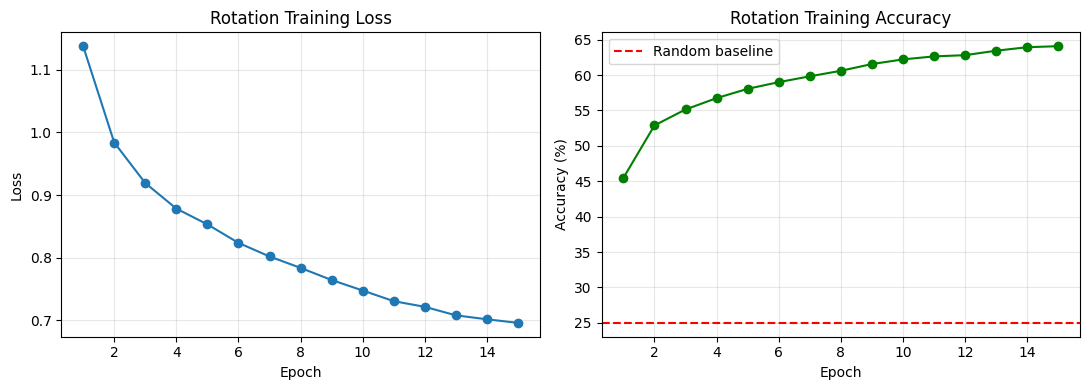

Final rotation checkpoint saved.


In [16]:
epochs = range(1, rotation_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, rotation_history["loss"], marker="o")
axes[0].set_title("Rotation Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    rotation_history["accuracy"],
    marker="o",
    color="green"
)
axes[1].axhline(
    25,
    color="red",
    linestyle="--",
    label="Random baseline"
)
axes[1].set_title("Rotation Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

torch.save(
    {
        "seed": SEED,
        "epochs": rotation_epochs,
        "encoder_state_dict": rotation_encoder.state_dict(),
        "rotation_head_state_dict": rotation_head.state_dict(),
        "final_loss": rotation_history["loss"][-1],
        "final_accuracy": rotation_history["accuracy"][-1]
    },
    "/content/checkpoints/rotation_resnet18_final.pt"
)

print("Final rotation checkpoint saved.")

## Linear Evaluation of the Rotation Encoder

I remove the rotation head and freeze the encoder. Only a new linear classifier is trained using the same 500 labeled images from Part A.

In [17]:
for parameter in rotation_encoder.parameters():
    parameter.requires_grad = False

rotation_encoder.eval()

torch.manual_seed(SEED)

rotation_linear_classifier = nn.Linear(512, 10).to(device)

frozen_encoder_parameters = sum(
    parameter.numel()
    for parameter in rotation_encoder.parameters()
    if parameter.requires_grad
)

trainable_classifier_parameters = sum(
    parameter.numel()
    for parameter in rotation_linear_classifier.parameters()
    if parameter.requires_grad
)

print("Trainable encoder parameters:", frozen_encoder_parameters)
print(
    "Trainable linear classifier parameters:",
    trainable_classifier_parameters
)

Trainable encoder parameters: 0
Trainable linear classifier parameters: 5130


## Train the Rotation Linear Classifier

Only the linear classifier is trained for 20 epochs. The rotation encoder remains frozen.

In [18]:
linear_epochs = 20
linear_loss_function = nn.CrossEntropyLoss()

rotation_linear_optimizer = torch.optim.AdamW(
    rotation_linear_classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

rotation_linear_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    rotation_linear_optimizer,
    T_max=linear_epochs
)

rotation_linear_history = {
    "loss": [],
    "accuracy": []
}

for epoch in range(1, linear_epochs + 1):
    rotation_encoder.eval()
    rotation_linear_classifier.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    for images, labels in supervised_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            features = rotation_encoder(images)

        predictions = rotation_linear_classifier(features)
        loss = linear_loss_function(predictions, labels)

        rotation_linear_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        rotation_linear_optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct_predictions += (
            predictions.argmax(dim=1) == labels
        ).sum().item()
        total_images += batch_size

    epoch_loss = running_loss / total_images
    epoch_accuracy = 100 * correct_predictions / total_images

    rotation_linear_history["loss"].append(epoch_loss)
    rotation_linear_history["accuracy"].append(epoch_accuracy)

    rotation_linear_scheduler.step()

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch 01 | Loss: 2.3486 | Training Accuracy: 13.60%
Epoch 02 | Loss: 2.1744 | Training Accuracy: 18.40%
Epoch 03 | Loss: 2.0754 | Training Accuracy: 26.00%
Epoch 04 | Loss: 2.0014 | Training Accuracy: 27.40%
Epoch 05 | Loss: 1.9181 | Training Accuracy: 34.60%
Epoch 06 | Loss: 1.8697 | Training Accuracy: 35.60%
Epoch 07 | Loss: 1.8401 | Training Accuracy: 39.40%
Epoch 08 | Loss: 1.7931 | Training Accuracy: 38.60%
Epoch 09 | Loss: 1.7677 | Training Accuracy: 40.80%
Epoch 10 | Loss: 1.7431 | Training Accuracy: 42.40%
Epoch 11 | Loss: 1.7171 | Training Accuracy: 43.00%
Epoch 12 | Loss: 1.7043 | Training Accuracy: 42.60%
Epoch 13 | Loss: 1.6790 | Training Accuracy: 46.00%
Epoch 14 | Loss: 1.6755 | Training Accuracy: 46.60%
Epoch 15 | Loss: 1.6660 | Training Accuracy: 45.40%
Epoch 16 | Loss: 1.6721 | Training Accuracy: 45.80%
Epoch 17 | Loss: 1.6608 | Training Accuracy: 46.40%
Epoch 18 | Loss: 1.6664 | Training Accuracy: 44.20%
Epoch 19 | Loss: 1.6655 | Training Accuracy: 43.80%
Epoch 20 | L

## Rotation Model Test Accuracy

I evaluate the frozen rotation encoder and its trained linear classifier on the STL-10 test set.

In [19]:
rotation_encoder.eval()
rotation_linear_classifier.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing Rotation Encoder"):
        images = images.to(device)
        labels = labels.to(device)

        features = rotation_encoder(images)
        predictions = rotation_linear_classifier(features)

        loss = linear_loss_function(predictions, labels)

        test_loss_sum += loss.item() * labels.size(0)
        test_correct += (
            predictions.argmax(dim=1) == labels
        ).sum().item()
        test_total += labels.size(0)

rotation_test_loss = test_loss_sum / test_total
rotation_test_accuracy = 100 * test_correct / test_total

print(f"Test Loss: {rotation_test_loss:.4f}")
print(f"Test Accuracy: {rotation_test_accuracy:.2f}%")

Testing Rotation Encoder:   0%|          | 0/32 [00:00<?, ?it/s]

Test Loss: 1.6903
Test Accuracy: 41.49%


### Part B Result

The frozen rotation encoder reached **41.49% test accuracy** after training only a linear classifier with 500 labeled images.

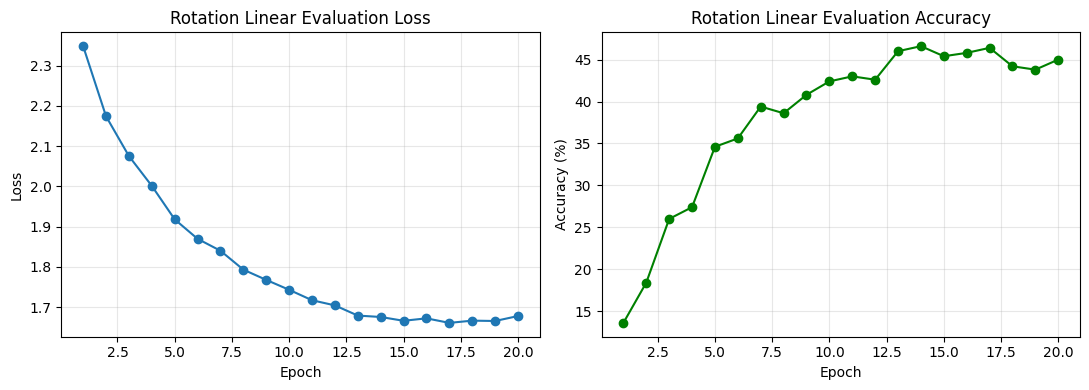

Rotation linear-evaluation checkpoint saved.


In [20]:
epochs = range(1, linear_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    epochs,
    rotation_linear_history["loss"],
    marker="o"
)
axes[0].set_title("Rotation Linear Evaluation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    rotation_linear_history["accuracy"],
    marker="o",
    color="green"
)
axes[1].set_title("Rotation Linear Evaluation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

torch.save(
    {
        "seed": SEED,
        "encoder_state_dict": rotation_encoder.state_dict(),
        "classifier_state_dict": rotation_linear_classifier.state_dict(),
        "linear_epochs": linear_epochs,
        "test_loss": rotation_test_loss,
        "test_accuracy": rotation_test_accuracy
    },
    "/content/checkpoints/rotation_linear_evaluation.pt"
)

print("Rotation linear-evaluation checkpoint saved.")

# Part C — SimCLR Contrastive Learning

**Question:** Use about 20,000 unlabeled images, create two augmented views per image, use four augmentations, cosine similarity, temperature 0.2 and an MLP projection head.

I select 20,000 unlabeled images using my seed.

In [21]:
simclr_rng = np.random.default_rng(SEED)

simclr_indices = simclr_rng.choice(
    len(unlabeled_raw),
    size=20000,
    replace=False
)

simclr_base_subset = Subset(
    unlabeled_raw,
    simclr_indices
)

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        96,
        scale=(0.6, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,
        hue=0.1
    ),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(stl_mean, stl_std)
])


class TwoViewDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        image, _ = self.base_dataset[index]

        view_one = self.transform(image)
        view_two = self.transform(image)

        return view_one, view_two


simclr_dataset = TwoViewDataset(
    simclr_base_subset,
    simclr_transform
)

simclr_generator = torch.Generator()
simclr_generator.manual_seed(SEED)

simclr_loader = DataLoader(
    simclr_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
    generator=simclr_generator
)

view_one, view_two = next(iter(simclr_loader))

print("SimCLR images:", len(simclr_dataset))
print("View 1 batch shape:", view_one.shape)
print("View 2 batch shape:", view_two.shape)

SimCLR images: 20000
View 1 batch shape: torch.Size([128, 3, 96, 96])
View 2 batch shape: torch.Size([128, 3, 96, 96])


## Check the Two Augmented Views

The two views come from the same original image but receive different random augmentations.

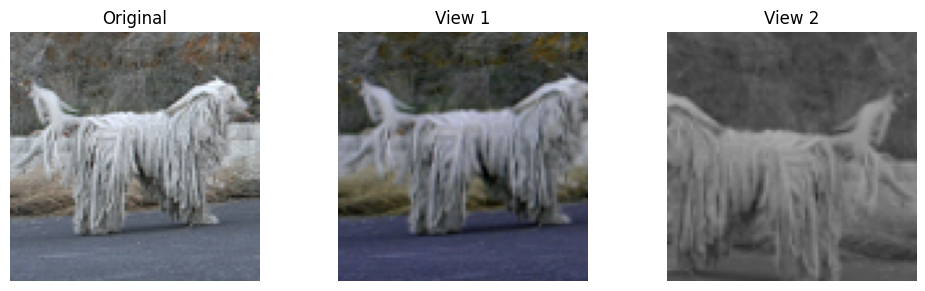

In [22]:
def show_normalized_tensor(tensor):
    image = tensor.detach().cpu().permute(1, 2, 0)

    mean = torch.tensor(stl_mean)
    std = torch.tensor(stl_std)

    image = image * std + mean
    return image.clamp(0, 1)


original_image, _ = simclr_base_subset[0]

augmented_view_one = simclr_transform(original_image)
augmented_view_two = simclr_transform(original_image)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(original_image)
axes[0].set_title("Original")

axes[1].imshow(show_normalized_tensor(augmented_view_one))
axes[1].set_title("View 1")

axes[2].imshow(show_normalized_tensor(augmented_view_two))
axes[2].set_title("View 2")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## SimCLR Model

The model contains a ResNet-18 encoder and an MLP projection head. The projection head is used only during contrastive training.

In [23]:
torch.manual_seed(SEED)

simclr_encoder = ResNet18Encoder().to(device)

projection_head = nn.Sequential(
    nn.Linear(512, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, 128)
).to(device)

with torch.no_grad():
    sample_images = view_one[:4].to(device)

    sample_features = simclr_encoder(sample_images)
    sample_projections = projection_head(sample_features)

print("Encoder output shape:", sample_features.shape)
print("Projection output shape:", sample_projections.shape)

Encoder output shape: torch.Size([4, 512])
Projection output shape: torch.Size([4, 128])


## Contrastive Loss

I use cosine similarity with temperature \( \tau = 0.2 \). Two views of the same image are treated as a positive pair.

In [24]:
temperature = 0.2


def nt_xent_loss(projection_one, projection_two, temperature=0.2):
    projection_one = F.normalize(projection_one, dim=1)
    projection_two = F.normalize(projection_two, dim=1)

    batch_size = projection_one.size(0)

    projections = torch.cat(
        [projection_one, projection_two],
        dim=0
    )

    similarity = projections @ projections.T
    similarity = similarity / temperature

    self_mask = torch.eye(
        2 * batch_size,
        device=similarity.device,
        dtype=torch.bool
    )

    similarity = similarity.masked_fill(
        self_mask,
        torch.finfo(similarity.dtype).min
    )

    positive_targets = (
        torch.arange(2 * batch_size, device=similarity.device)
        + batch_size
    ) % (2 * batch_size)

    return F.cross_entropy(
        similarity,
        positive_targets
    )


with torch.no_grad():
    sample_view_one = view_one[:8].to(device)
    sample_view_two = view_two[:8].to(device)

    projection_one = projection_head(
        simclr_encoder(sample_view_one)
    )

    projection_two = projection_head(
        simclr_encoder(sample_view_two)
    )

    sample_loss = nt_xent_loss(
        projection_one,
        projection_two,
        temperature
    )

print("Temperature:", temperature)
print("Sample contrastive loss:", round(sample_loss.item(), 4))

Temperature: 0.2
Sample contrastive loss: 2.7336


## Train SimCLR

The encoder and projection head are trained together for 20 epochs. The contrastive loss should decrease as matching views move closer in the representation space.

In [25]:
simclr_epochs = 20

simclr_optimizer = torch.optim.AdamW(
    list(simclr_encoder.parameters())
    + list(projection_head.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

simclr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    simclr_optimizer,
    T_max=simclr_epochs
)

simclr_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

simclr_history = {
    "loss": [],
    "time": []
}

for epoch in range(1, simclr_epochs + 1):
    simclr_encoder.train()
    projection_head.train()

    start_time = time.time()
    running_loss = 0.0
    total_batches = 0

    progress_bar = tqdm(
        simclr_loader,
        desc=f"SimCLR Epoch {epoch}/{simclr_epochs}"
    )

    for view_one, view_two in progress_bar:
        view_one = view_one.to(device, non_blocking=True)
        view_two = view_two.to(device, non_blocking=True)

        simclr_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):
            features_one = simclr_encoder(view_one)
            features_two = simclr_encoder(view_two)

            projection_one = projection_head(features_one)
            projection_two = projection_head(features_two)

            loss = nt_xent_loss(
                projection_one,
                projection_two,
                temperature
            )

        simclr_scaler.scale(loss).backward()
        simclr_scaler.step(simclr_optimizer)
        simclr_scaler.update()

        running_loss += loss.item()
        total_batches += 1

    epoch_loss = running_loss / total_batches
    epoch_time = time.time() - start_time

    simclr_history["loss"].append(epoch_loss)
    simclr_history["time"].append(epoch_time)

    simclr_scheduler.step()

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Time: {epoch_time / 60:.2f} min"
    )

    torch.save(
        {
            "epoch": epoch,
            "encoder_state_dict": simclr_encoder.state_dict(),
            "projection_head_state_dict": projection_head.state_dict(),
            "optimizer_state_dict": simclr_optimizer.state_dict(),
            "history": simclr_history
        },
        "/content/checkpoints/simclr_latest.pt"
    )

SimCLR Epoch 1/20:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 01 | Loss: 3.2136 | Time: 1.84 min


SimCLR Epoch 2/20:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 02 | Loss: 2.2175 | Time: 1.84 min


SimCLR Epoch 3/20:   0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch 18 | Loss: 1.5666 | Time: 1.90 min


SimCLR Epoch 19/20:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 19 | Loss: 1.5635 | Time: 1.88 min


SimCLR Epoch 20/20:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 20 | Loss: 1.5637 | Time: 1.90 min


### SimCLR Pretraining Result

The contrastive loss decreased from 3.2136 to 1.5637 over 20 epochs. This shows that the model learned to bring two augmented views of the same image closer together.

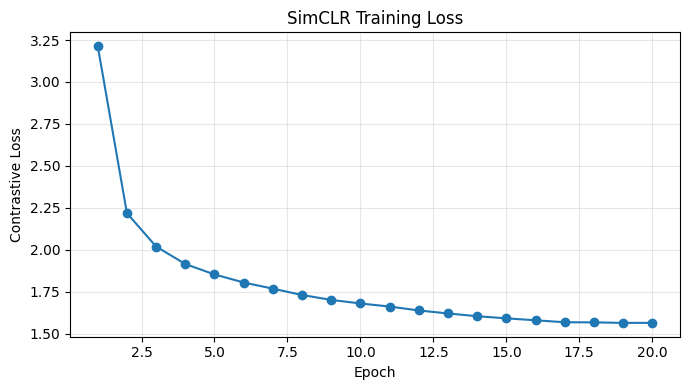

Final SimCLR checkpoint saved.
SimCLR subset indices saved.


In [26]:
epochs = range(1, simclr_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    simclr_history["loss"],
    marker="o"
)

plt.title("SimCLR Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

np.save(
    "/content/checkpoints/simclr_20000_indices.npy",
    simclr_indices
)

torch.save(
    {
        "seed": SEED,
        "epochs": simclr_epochs,
        "temperature": temperature,
        "encoder_state_dict": simclr_encoder.state_dict(),
        "projection_head_state_dict": projection_head.state_dict(),
        "final_loss": simclr_history["loss"][-1]
    },
    "/content/checkpoints/simclr_resnet18_final.pt"
)

print("Final SimCLR checkpoint saved.")
print("SimCLR subset indices saved.")

## Linear Evaluation of the SimCLR Encoder

I remove the projection head and freeze the SimCLR encoder. Only a new linear classifier is trained using the same 500 labeled images.

In [27]:
for parameter in simclr_encoder.parameters():
    parameter.requires_grad = False

simclr_encoder.eval()

torch.manual_seed(SEED)

simclr_linear_classifier = nn.Linear(512, 10).to(device)

frozen_encoder_parameters = sum(
    parameter.numel()
    for parameter in simclr_encoder.parameters()
    if parameter.requires_grad
)

trainable_classifier_parameters = sum(
    parameter.numel()
    for parameter in simclr_linear_classifier.parameters()
    if parameter.requires_grad
)

print("Trainable encoder parameters:", frozen_encoder_parameters)
print(
    "Trainable linear classifier parameters:",
    trainable_classifier_parameters
)

Trainable encoder parameters: 0
Trainable linear classifier parameters: 5130


## Train the SimCLR Linear Classifier

Only the new linear classifier is trained for 20 epochs. The SimCLR encoder remains frozen.

In [28]:
simclr_linear_epochs = 20
simclr_linear_loss_function = nn.CrossEntropyLoss()

simclr_linear_optimizer = torch.optim.AdamW(
    simclr_linear_classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

simclr_linear_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    simclr_linear_optimizer,
    T_max=simclr_linear_epochs
)

simclr_linear_history = {
    "loss": [],
    "accuracy": []
}

for epoch in range(1, simclr_linear_epochs + 1):
    simclr_encoder.eval()
    simclr_linear_classifier.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    for images, labels in supervised_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            features = simclr_encoder(images)

        predictions = simclr_linear_classifier(features)
        loss = simclr_linear_loss_function(predictions, labels)

        simclr_linear_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        simclr_linear_optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct_predictions += (
            predictions.argmax(dim=1) == labels
        ).sum().item()
        total_images += batch_size

    epoch_loss = running_loss / total_images
    epoch_accuracy = 100 * correct_predictions / total_images

    simclr_linear_history["loss"].append(epoch_loss)
    simclr_linear_history["accuracy"].append(epoch_accuracy)

    simclr_linear_scheduler.step()

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch 01 | Loss: 2.2625 | Training Accuracy: 19.40%
Epoch 02 | Loss: 1.7903 | Training Accuracy: 38.60%
Epoch 03 | Loss: 1.5442 | Training Accuracy: 46.60%
Epoch 04 | Loss: 1.4402 | Training Accuracy: 50.40%
Epoch 05 | Loss: 1.3940 | Training Accuracy: 49.40%
Epoch 06 | Loss: 1.3383 | Training Accuracy: 52.60%
Epoch 07 | Loss: 1.3067 | Training Accuracy: 53.00%
Epoch 08 | Loss: 1.2814 | Training Accuracy: 53.40%
Epoch 09 | Loss: 1.2615 | Training Accuracy: 53.60%
Epoch 10 | Loss: 1.2203 | Training Accuracy: 56.00%
Epoch 11 | Loss: 1.2194 | Training Accuracy: 57.40%
Epoch 12 | Loss: 1.1961 | Training Accuracy: 57.00%
Epoch 13 | Loss: 1.1805 | Training Accuracy: 59.40%
Epoch 14 | Loss: 1.1729 | Training Accuracy: 58.00%
Epoch 15 | Loss: 1.1779 | Training Accuracy: 57.20%
Epoch 16 | Loss: 1.1927 | Training Accuracy: 57.80%
Epoch 17 | Loss: 1.1808 | Training Accuracy: 57.60%
Epoch 18 | Loss: 1.1764 | Training Accuracy: 57.60%
Epoch 19 | Loss: 1.1789 | Training Accuracy: 58.20%
Epoch 20 | L

## SimCLR Test Accuracy

I evaluate the frozen SimCLR encoder and its trained linear classifier on the STL-10 test set.

In [29]:
simclr_encoder.eval()
simclr_linear_classifier.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing SimCLR Encoder"):
        images = images.to(device)
        labels = labels.to(device)

        features = simclr_encoder(images)
        predictions = simclr_linear_classifier(features)

        loss = simclr_linear_loss_function(
            predictions,
            labels
        )

        test_loss_sum += loss.item() * labels.size(0)
        test_correct += (
            predictions.argmax(dim=1) == labels
        ).sum().item()
        test_total += labels.size(0)

simclr_test_loss = test_loss_sum / test_total
simclr_test_accuracy = 100 * test_correct / test_total

print(f"Test Loss: {simclr_test_loss:.4f}")
print(f"Test Accuracy: {simclr_test_accuracy:.2f}%")

Testing SimCLR Encoder:   0%|          | 0/32 [00:00<?, ?it/s]

Test Loss: 1.4308
Test Accuracy: 48.48%


### Part C Result

The frozen SimCLR encoder reached **48.48% test accuracy**. It performed better than both the supervised and rotation-based models.

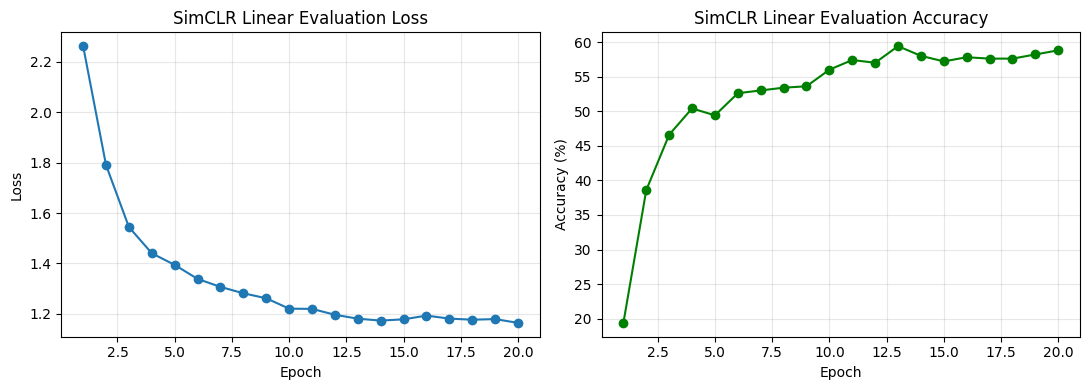

SimCLR linear-evaluation checkpoint saved.


In [30]:
epochs = range(1, simclr_linear_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    epochs,
    simclr_linear_history["loss"],
    marker="o"
)
axes[0].set_title("SimCLR Linear Evaluation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    simclr_linear_history["accuracy"],
    marker="o",
    color="green"
)
axes[1].set_title("SimCLR Linear Evaluation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

torch.save(
    {
        "seed": SEED,
        "encoder_state_dict": simclr_encoder.state_dict(),
        "classifier_state_dict": simclr_linear_classifier.state_dict(),
        "linear_epochs": simclr_linear_epochs,
        "test_loss": simclr_test_loss,
        "test_accuracy": simclr_test_accuracy
    },
    "/content/checkpoints/simclr_linear_evaluation.pt"
)

print("SimCLR linear-evaluation checkpoint saved.")

# Part D — Nearest-Neighbor Visualization

**Question:** For the supervised, rotation and SimCLR encoders, retrieve the top five nearest test images using cosine similarity.

I first extract and normalize the 512-dimensional test embeddings from all three encoders.

In [31]:
@torch.no_grad()
def extract_embeddings(encoder, data_loader):
    encoder.eval()
    all_embeddings = []

    for images, _ in tqdm(data_loader, desc="Extracting embeddings"):
        images = images.to(device)

        embeddings = encoder(images)
        embeddings = F.normalize(embeddings, dim=1)

        all_embeddings.append(embeddings.cpu())

    return torch.cat(all_embeddings, dim=0)


supervised_embeddings = extract_embeddings(
    supervised_encoder,
    test_loader
)

rotation_embeddings = extract_embeddings(
    rotation_encoder,
    test_loader
)

simclr_embeddings = extract_embeddings(
    simclr_encoder,
    test_loader
)

test_labels = torch.tensor(test_dataset.labels)

print("Supervised embeddings:", supervised_embeddings.shape)
print("Rotation embeddings:", rotation_embeddings.shape)
print("SimCLR embeddings:", simclr_embeddings.shape)
print("Test labels:", test_labels.shape)

Extracting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

Supervised embeddings: torch.Size([8000, 512])
Rotation embeddings: torch.Size([8000, 512])
SimCLR embeddings: torch.Size([8000, 512])
Test labels: torch.Size([8000])


## Select the Query Images

I use the same dog, ship and car query images for all three encoders.

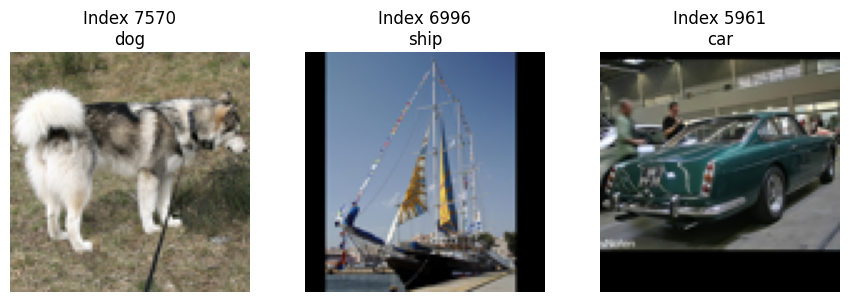

Query indices: [7570, 6996, 5961]
Query classes: ['dog', 'ship', 'car']


In [32]:
query_rng = np.random.default_rng(SEED)

query_class_ids = [CLS_B, CLS_A, 2]
query_indices = []

for class_id in query_class_ids:
    matching_indices = np.where(
        test_labels.numpy() == class_id
    )[0]

    selected_query = query_rng.choice(matching_indices)
    query_indices.append(int(selected_query))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for ax, query_index in zip(axes, query_indices):
    image, label = test_raw[query_index]

    ax.imshow(image)
    ax.set_title(
        f"Index {query_index}\n{class_names[label]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Query indices:", query_indices)
print(
    "Query classes:",
    [class_names[test_raw[index][1]] for index in query_indices]
)

## Retrieve the Top-5 Nearest Neighbors

For each query, I calculate cosine similarity with all test embeddings. The query itself is removed before selecting the five closest images.

In [33]:
os.makedirs("/content/figures", exist_ok=True)


def show_nearest_neighbors(
    embeddings,
    query_indices,
    encoder_name,
    file_name
):
    neighbor_results = {}

    fig, axes = plt.subplots(
        len(query_indices),
        6,
        figsize=(15, 7)
    )

    for row, query_index in enumerate(query_indices):
        query_embedding = embeddings[query_index]

        similarities = embeddings @ query_embedding
        similarities[query_index] = -float("inf")

        neighbor_indices = torch.topk(
            similarities,
            k=5
        ).indices.tolist()

        neighbor_results[query_index] = neighbor_indices

        query_image, query_label = test_raw[query_index]

        axes[row, 0].imshow(query_image)
        axes[row, 0].set_title(
            f"Query\n{class_names[query_label]}"
        )
        axes[row, 0].axis("off")

        for column, neighbor_index in enumerate(
            neighbor_indices,
            start=1
        ):
            neighbor_image, neighbor_label = test_raw[
                neighbor_index
            ]

            similarity_value = similarities[
                neighbor_index
            ].item()

            axes[row, column].imshow(neighbor_image)
            axes[row, column].set_title(
                f"{class_names[neighbor_label]}\n"
                f"cos={similarity_value:.3f}"
            )
            axes[row, column].axis("off")

    fig.suptitle(
        f"{encoder_name} — Top-5 Nearest Neighbors",
        fontsize=14
    )

    plt.tight_layout()
    plt.savefig(
        f"/content/figures/{file_name}",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    return neighbor_results

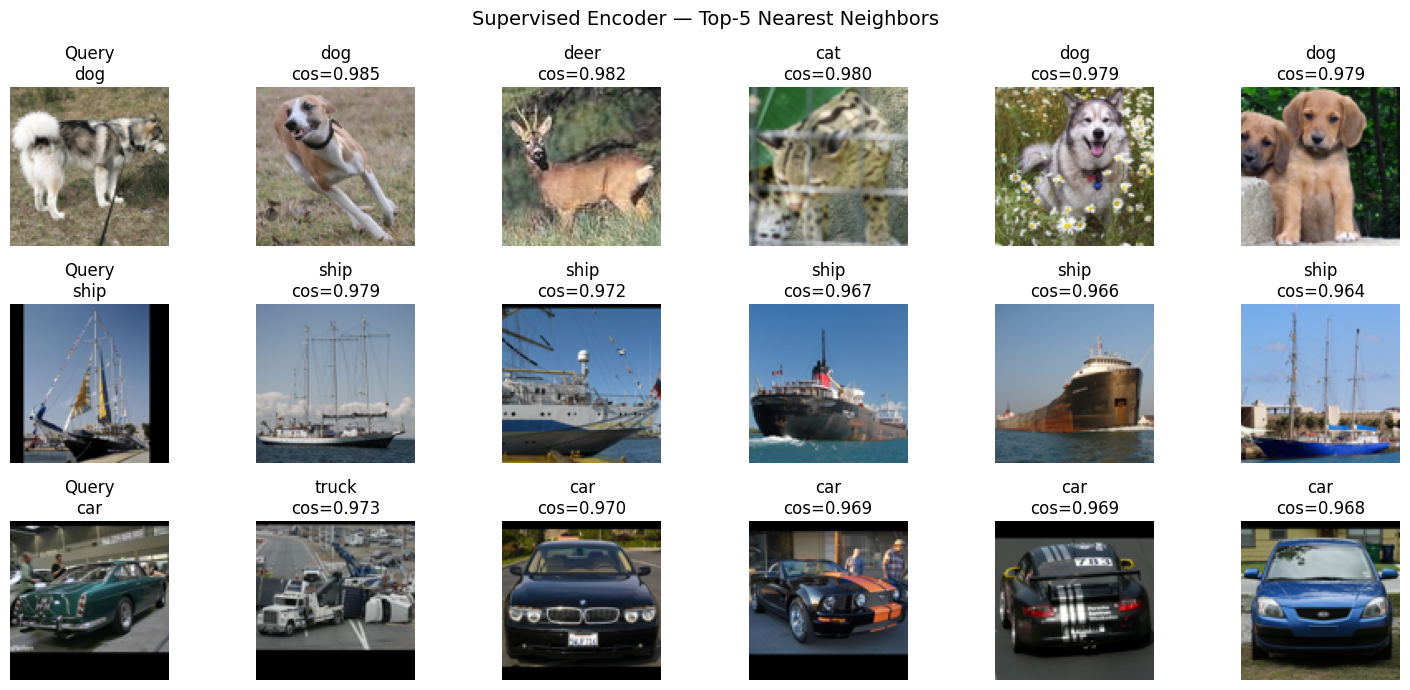

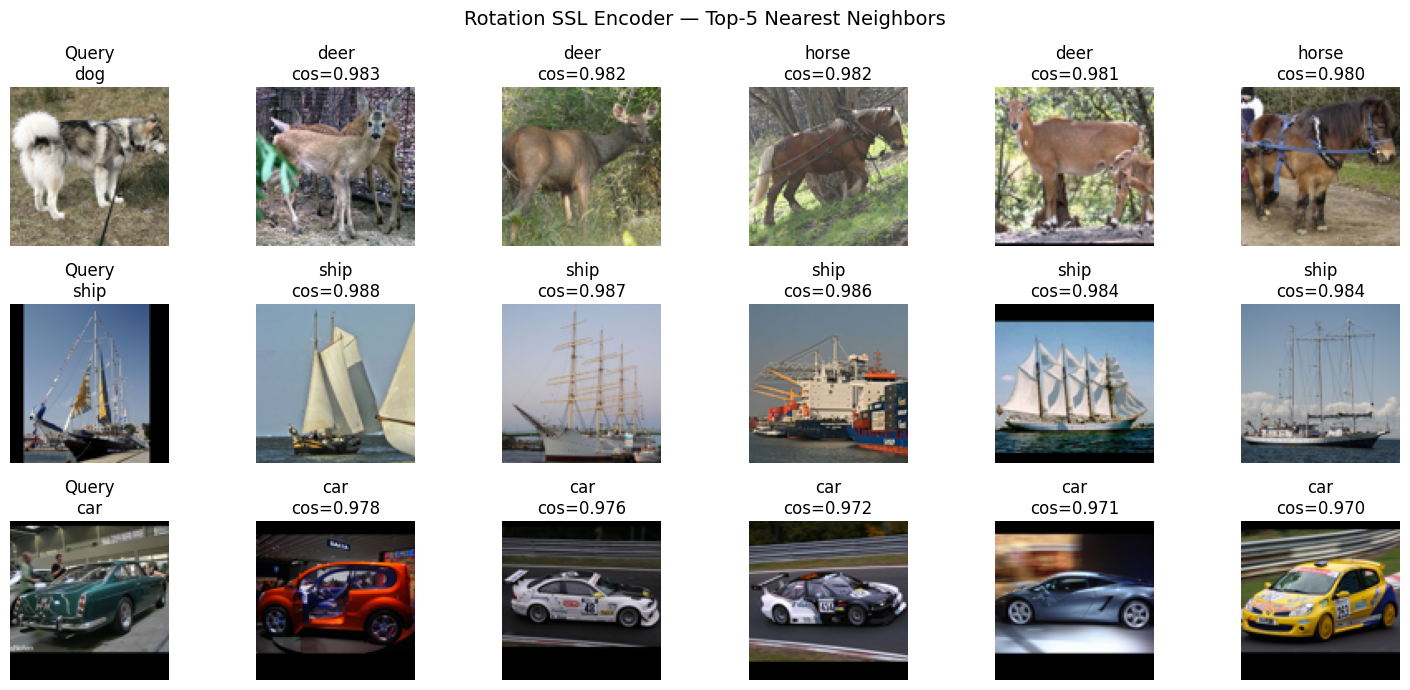

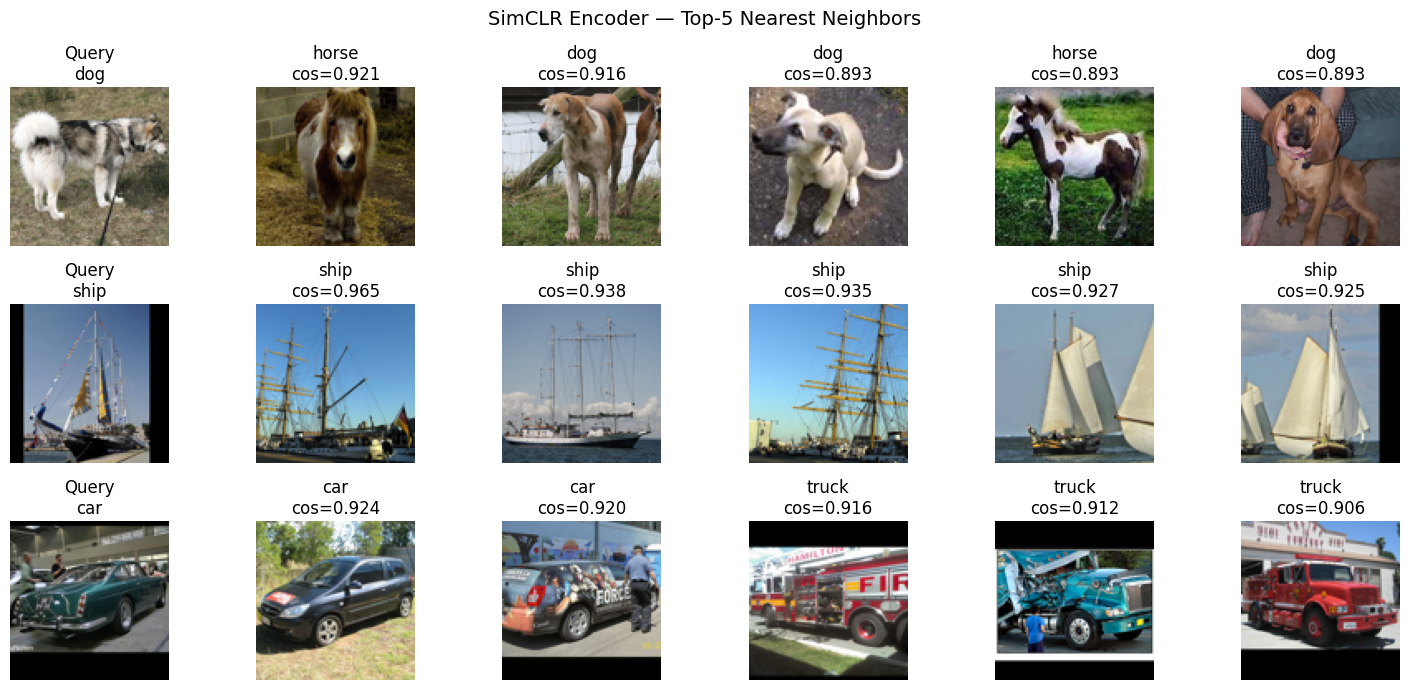

In [34]:
supervised_neighbors = show_nearest_neighbors(
    supervised_embeddings,
    query_indices,
    "Supervised Encoder",
    "supervised_neighbors.png"
)

rotation_neighbors = show_nearest_neighbors(
    rotation_embeddings,
    query_indices,
    "Rotation SSL Encoder",
    "rotation_neighbors.png"
)

simclr_neighbors = show_nearest_neighbors(
    simclr_embeddings,
    query_indices,
    "SimCLR Encoder",
    "simclr_neighbors.png"
)

## Nearest-Neighbor Class Match

A stronger representation should retrieve more images from the same class as the query.

In [35]:
def summarize_neighbors(neighbor_results, model_name):
    rows = []

    for query_index, neighbor_indices in neighbor_results.items():
        query_label = test_raw[query_index][1]

        neighbor_labels = [
            test_raw[index][1]
            for index in neighbor_indices
        ]

        matches = sum(
            label == query_label
            for label in neighbor_labels
        )

        rows.append({
            "Model": model_name,
            "Query": class_names[query_label],
            "Matching Neighbors": matches,
            "Total Neighbors": 5,
            "Match Rate (%)": 100 * matches / 5,
            "Retrieved Classes": ", ".join(
                class_names[label]
                for label in neighbor_labels
            )
        })

    return rows


neighbor_summary = pd.DataFrame(
    summarize_neighbors(
        supervised_neighbors,
        "Supervised"
    )
    + summarize_neighbors(
        rotation_neighbors,
        "Rotation SSL"
    )
    + summarize_neighbors(
        simclr_neighbors,
        "SimCLR"
    )
)

display(neighbor_summary)

overall_neighbor_match = (
    neighbor_summary
    .groupby("Model")["Matching Neighbors"]
    .sum()
    .reset_index()
)

overall_neighbor_match["Total Neighbors"] = 15

overall_neighbor_match["Overall Match Rate (%)"] = (
    100
    * overall_neighbor_match["Matching Neighbors"]
    / overall_neighbor_match["Total Neighbors"]
)

display(overall_neighbor_match)

,Model,Query,Matching Neighbors,Total Neighbors,Match Rate (%),Retrieved Classes
0,Supervised,dog,3,5,60.0,"dog, deer, cat, dog, dog"
1,Supervised,ship,5,5,100.0,"ship, ship, ship, ship, ship"
2,Supervised,car,4,5,80.0,"truck, car, car, car, car"
3,Rotation SSL,dog,0,5,0.0,"deer, deer, horse, deer, horse"
4,Rotation SSL,ship,5,5,100.0,"ship, ship, ship, ship, ship"
5,Rotation SSL,car,5,5,100.0,"car, car, car, car, car"
6,SimCLR,dog,3,5,60.0,"horse, dog, dog, horse, dog"
7,SimCLR,ship,5,5,100.0,"ship, ship, ship, ship, ship"
8,SimCLR,car,2,5,40.0,"car, car, truck, truck, truck"


,Model,Matching Neighbors,Total Neighbors,Overall Match Rate (%)
0,Rotation SSL,10,15,66.666667
1,SimCLR,10,15,66.666667
2,Supervised,12,15,80.000000


## Model Comparison

I compare the three models using test accuracy and the class-match rate of their nearest neighbors.

In [36]:
neighbor_rate_map = dict(
    zip(
        overall_neighbor_match["Model"],
        overall_neighbor_match["Overall Match Rate (%)"]
    )
)

comparison_table = pd.DataFrame({
    "Model": [
        "Supervised",
        "Rotation SSL",
        "SimCLR"
    ],
    "Pretraining Data": [
        "500 labeled images",
        "100,000 unlabeled images",
        "20,000 unlabeled images"
    ],
    "Test Loss": [
        supervised_test_loss,
        rotation_test_loss,
        simclr_test_loss
    ],
    "Test Accuracy (%)": [
        supervised_test_accuracy,
        rotation_test_accuracy,
        simclr_test_accuracy
    ],
    "Neighbor Match Rate (%)": [
        neighbor_rate_map["Supervised"],
        neighbor_rate_map["Rotation SSL"],
        neighbor_rate_map["SimCLR"]
    ]
})

comparison_table["Test Loss"] = (
    comparison_table["Test Loss"].round(4)
)

comparison_table["Test Accuracy (%)"] = (
    comparison_table["Test Accuracy (%)"].round(2)
)

comparison_table["Neighbor Match Rate (%)"] = (
    comparison_table["Neighbor Match Rate (%)"].round(2)
)

display(comparison_table)

,Model,Pretraining Data,Test Loss,Test Accuracy (%),Neighbor Match Rate (%)
0,Supervised,500 labeled images,1.6781,44.15,80.00
1,Rotation SSL,"100,000 unlabeled images",1.6903,41.49,66.67
2,SimCLR,"20,000 unlabeled images",1.4308,48.48,66.67


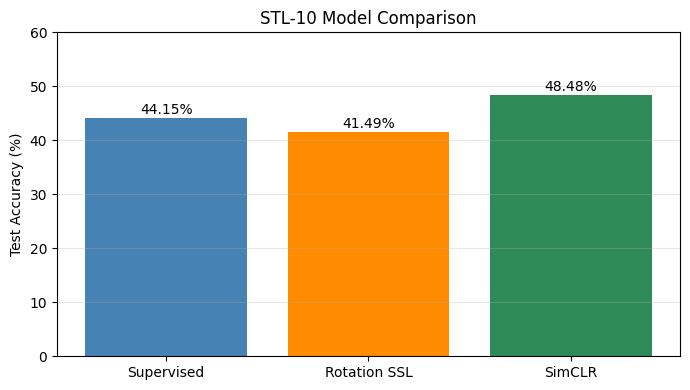

In [37]:
plt.figure(figsize=(7, 4))

bars = plt.bar(
    comparison_table["Model"],
    comparison_table["Test Accuracy (%)"],
    color=["steelblue", "darkorange", "seagreen"]
)

plt.ylabel("Test Accuracy (%)")
plt.title("STL-10 Model Comparison")
plt.ylim(0, 60)
plt.grid(axis="y", alpha=0.3)

for bar, accuracy in zip(
    bars,
    comparison_table["Test Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "/content/figures/model_accuracy_comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [38]:
print("NEIGHBOR RESULTS")
print("----------------")

print(
    neighbor_summary[
        [
            "Model",
            "Query",
            "Matching Neighbors",
            "Retrieved Classes"
        ]
    ].to_string(index=False)
)

print("\nOVERALL MATCH RATE")
print("------------------")

print(
    overall_neighbor_match.to_string(index=False)
)

NEIGHBOR RESULTS
----------------
       Model Query  Matching Neighbors              Retrieved Classes
  Supervised   dog                   3       dog, deer, cat, dog, dog
  Supervised  ship                   5   ship, ship, ship, ship, ship
  Supervised   car                   4      truck, car, car, car, car
Rotation SSL   dog                   0 deer, deer, horse, deer, horse
Rotation SSL  ship                   5   ship, ship, ship, ship, ship
Rotation SSL   car                   5        car, car, car, car, car
      SimCLR   dog                   3    horse, dog, dog, horse, dog
      SimCLR  ship                   5   ship, ship, ship, ship, ship
      SimCLR   car                   2  car, car, truck, truck, truck

OVERALL MATCH RATE
------------------
       Model  Matching Neighbors  Total Neighbors  Overall Match Rate (%)
Rotation SSL                  10               15               66.666667
      SimCLR                  10               15               66.666667
  Sup

## Final Comparison

SimCLR performed best with **48.48% test accuracy**. The supervised model reached **44.15%**, while the rotation model reached **41.49%**.

SimCLR performed better because it learned from 20,000 unlabeled images and was trained to recognize two changed versions of the same image as a matching pair. The crop, flip, color and grayscale augmentations helped it learn features that were less dependent on the exact appearance of an image.

The supervised model learned directly from class labels, but it had only 500 training images. Its training accuracy reached 75.40%, while its test accuracy was 44.15%. This large difference shows that it overfitted the small training set.

The rotation model used all 100,000 unlabeled images, but its final accuracy was the lowest. Rotation prediction helped it learn shapes and object orientation, but these features were not always enough to separate the ten object classes. The rotation task is also less closely related to object classification than the SimCLR objective.

The nearest-neighbor results showed that the encoders did not always group images only by class. Some incorrect neighbors had similar colors, backgrounds, shapes or object positions. SimCLR generally produced more meaningful groups because it was trained to ignore changes in crop, direction and color. The class-match table gives a numerical summary of this behavior.

The supervised model could be improved with more labeled images, stronger augmentation and additional regularization. The rotation model could be improved with longer pretraining or another self-supervised task that focuses more directly on object meaning. SimCLR could be improved by using more unlabeled images, a larger batch size and more pretraining epochs.

## Required Submission Files

I save the final metrics, run details and AI-use appendix required for submission.

In [39]:
from datetime import datetime
import torchvision

artifact_dir = "/content/submission_artifacts"
os.makedirs(artifact_dir, exist_ok=True)


# -------------------- METRICS.md --------------------

metrics_text = f"""# Metrics

## Main Results

| Model | Test Loss | Test Accuracy | Neighbor Match Rate |
|---|---:|---:|---:|
| Supervised | {supervised_test_loss:.4f} | {supervised_test_accuracy:.2f}% | {neighbor_rate_map["Supervised"]:.2f}% |
| Rotation SSL | {rotation_test_loss:.4f} | {rotation_test_accuracy:.2f}% | {neighbor_rate_map["Rotation SSL"]:.2f}% |
| SimCLR | {simclr_test_loss:.4f} | {simclr_test_accuracy:.2f}% | {neighbor_rate_map["SimCLR"]:.2f}% |

## Training Details

- Supervised images: 500
- Supervised epochs: {supervised_epochs}
- Final supervised training accuracy: {supervised_history["accuracy"][-1]:.2f}%
- Rotation images: 100,000
- Rotation epochs: {rotation_epochs}
- Final rotation accuracy: {rotation_history["accuracy"][-1]:.2f}%
- Rotation linear-evaluation epochs: {linear_epochs}
- SimCLR images: 20,000
- SimCLR epochs: {simclr_epochs}
- Temperature: {temperature}
- Final SimCLR loss: {simclr_history["loss"][-1]:.4f}
- SimCLR linear-evaluation epochs: {simclr_linear_epochs}
"""

with open(
    f"{artifact_dir}/METRICS.md",
    "w"
) as file:
    file.write(metrics_text)


# -------------------- RUN_LOG.txt --------------------

run_lines = [
    "STL-10 Representation Learning Run Log",
    "=" * 45,
    f"Created: {datetime.now()}",
    f"SID4: {SID4}",
    f"SEED: {SEED}",
    f"Device: {device}",
    f"GPU: {torch.cuda.get_device_name(0)}",
    f"PyTorch: {torch.__version__}",
    f"Torchvision: {torchvision.__version__}",
    ""
]

for epoch, (loss, accuracy) in enumerate(
    zip(
        supervised_history["loss"],
        supervised_history["accuracy"]
    ),
    start=1
):
    run_lines.append(
        f"Supervised Epoch {epoch:02d} | "
        f"Loss {loss:.4f} | Accuracy {accuracy:.2f}%"
    )

run_lines.append(
    f"Supervised Test | Loss {supervised_test_loss:.4f} | "
    f"Accuracy {supervised_test_accuracy:.2f}%"
)

for epoch, (loss, accuracy, epoch_time) in enumerate(
    zip(
        rotation_history["loss"],
        rotation_history["accuracy"],
        rotation_history["time"]
    ),
    start=1
):
    run_lines.append(
        f"Rotation Epoch {epoch:02d} | "
        f"Loss {loss:.4f} | Accuracy {accuracy:.2f}% | "
        f"Time {epoch_time / 60:.2f} min"
    )

run_lines.append(
    f"Rotation Test | Loss {rotation_test_loss:.4f} | "
    f"Accuracy {rotation_test_accuracy:.2f}%"
)

for epoch, (loss, epoch_time) in enumerate(
    zip(
        simclr_history["loss"],
        simclr_history["time"]
    ),
    start=1
):
    run_lines.append(
        f"SimCLR Epoch {epoch:02d} | "
        f"Loss {loss:.4f} | "
        f"Time {epoch_time / 60:.2f} min"
    )

run_lines.append(
    f"SimCLR Test | Loss {simclr_test_loss:.4f} | "
    f"Accuracy {simclr_test_accuracy:.2f}%"
)

run_lines.extend([
    "",
    "Observed warning:",
    "AssertionError: can only test a child process",
    "Fix: Changed DataLoader num_workers from 2 to 0."
])

with open(
    f"{artifact_dir}/RUN_LOG.txt",
    "w"
) as file:
    file.write("\n".join(run_lines))

